# CONVNEXT 5 epochs

Total YES images: 6846
Total NO images: 6846


Copying train images:   0%|          | 0/9584 [00:00<?, ?it/s]

Copying val images:   0%|          | 0/2054 [00:00<?, ?it/s]

Copying test images:   0%|          | 0/2054 [00:00<?, ?it/s]

TRAIN - Images: 9584, Labels: 6248
VAL - Images: 2054, Labels: 1891
TEST - Images: 2054, Labels: 1898
Let's use 2 GPUs! 🚀


...

Epoch 3/5 - Loss: 0.3085 - Accuracy: 0.8973


Epoch 4/5:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 4/5 - Loss: 0.3039 - Accuracy: 0.9007


Epoch 5/5:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 5/5 - Loss: 0.3122 - Accuracy: 0.8958


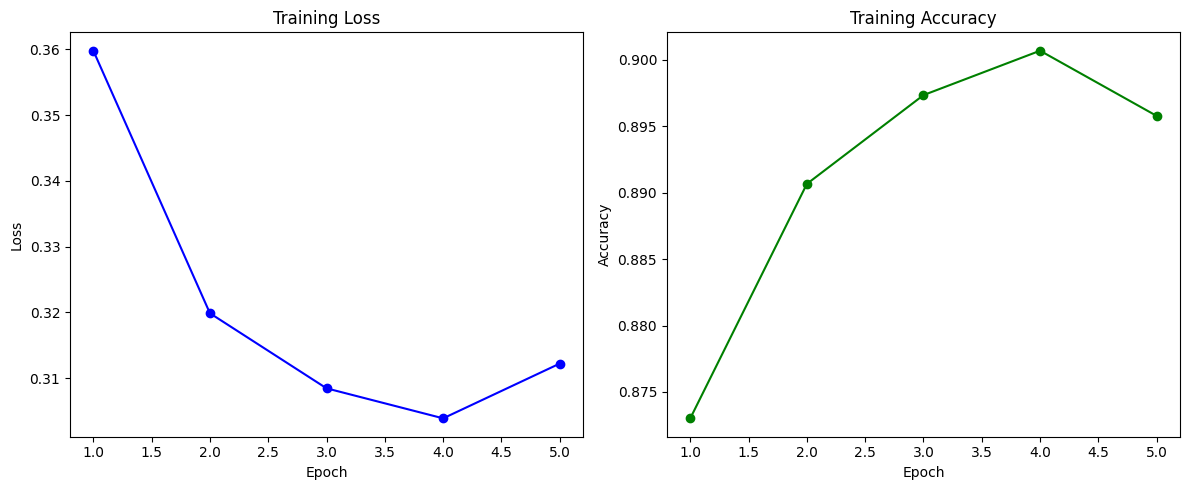

Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]


Classification Report:
               precision    recall  f1-score   support

          no       0.90      0.92      0.91      1027
         yes       0.92      0.90      0.91      1027

    accuracy                           0.91      2054
   macro avg       0.91      0.91      0.91      2054
weighted avg       0.91      0.91      0.91      2054



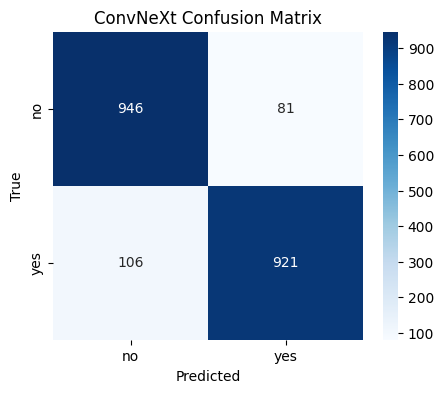

In [3]:
# ============================
# 1. Install Dependencies
# ============================

import os
import glob
import shutil
import random
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm # For notebook-friendly progress bars

# ============================
# 2. Dataset Preparation
# ============================
# Note: Adjust this path to your actual dataset location if different
base_dir = "/kaggle/input/tumor-dataset/dataset" 
yes_dir = os.path.join(base_dir, "yes")
no_dir  = os.path.join(base_dir, "no")

dataset_dir = "/kaggle/working/brain_tumor_bt"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dataset_dir, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, split, "labels"), exist_ok=True)

def write_label(img_path, out_dir, label_id):
    label_txt = os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    with open(os.path.join(out_dir, label_txt), "w") as f:
        f.write(f"{label_id} 0.5 0.5 1.0 1.0\n")

def collect_images(src):
    valid_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
    imgs = []
    for ext in valid_exts:
        imgs.extend(glob.glob(f"{src}/**/{ext}", recursive=True))
    return imgs

# Collect images
imgs_yes = collect_images(yes_dir)
imgs_no  = collect_images(no_dir)

print(f"Total YES images: {len(imgs_yes)}")
print(f"Total NO images: {len(imgs_no)}")

# ============================
# 3. Stratified Split
# ============================
def stratified_split(imgs_yes, imgs_no, test_size=0.15, val_size=0.15):
    train_yes, test_yes = train_test_split(imgs_yes, test_size=test_size, random_state=42)
    train_yes, val_yes  = train_test_split(train_yes, test_size=val_size/(1-test_size), random_state=42)
    
    train_no, test_no = train_test_split(imgs_no, test_size=test_size, random_state=42)
    train_no, val_no  = train_test_split(train_no, test_size=val_size/(1-test_size), random_state=42)

    train = [(f,1) for f in train_yes] + [(f,0) for f in train_no]
    val   = [(f,1) for f in val_yes]   + [(f,0) for f in val_no]
    test  = [(f,1) for f in test_yes]  + [(f,0) for f in test_no]
    return train, val, test

train, val, test = stratified_split(imgs_yes, imgs_no)

# ============================
# 4. Move images into class subfolders
# ============================
for split in ["train", "val", "test"]:
    for cls_name in ["no", "yes"]:
        os.makedirs(os.path.join(dataset_dir, split, "images", cls_name), exist_ok=True)

def move_images(split_data, split_name):
    # Added tqdm here for file copying progress
    for f, cls in tqdm(split_data, desc=f"Copying {split_name} images"):
        cls_name = "yes" if cls==1 else "no"
        dest = os.path.join(dataset_dir, split_name, "images", cls_name, os.path.basename(f))
        shutil.copy(f, dest)
        out_lbl = os.path.join(dataset_dir, split_name, "labels")
        write_label(f, out_lbl, cls)

move_images(train, "train")
move_images(val, "val")
move_images(test, "test")

# Debug counts
for split in ["train", "val", "test"]:
    img_dir_yes = os.path.join(dataset_dir, split, "images", "yes")
    img_dir_no = os.path.join(dataset_dir, split, "images", "no")
    lbl_dir = os.path.join(dataset_dir, split, "labels")
    num_images = len(os.listdir(img_dir_yes)) + len(os.listdir(img_dir_no))
    print(f"{split.upper()} - Images: {num_images}, Labels: {len(os.listdir(lbl_dir))}")

# ============================
# 5. ConvNeXt Classification
# ============================

# Data transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.ToTensor(),
])


train_dataset = datasets.ImageFolder(os.path.join(dataset_dir, "train/images"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(dataset_dir, "val/images"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(dataset_dir, "test/images"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load pre-trained ConvNeXt
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
num_ftrs = model.classifier[2].in_features
model.classifier[2] = nn.Sequential(
    nn.Dropout(0.5),      # prevent overfitting
    nn.Linear(num_ftrs, 2)    # binary classification
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Handle multi-GPU
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs! 🚀")
    # Wrap the model with DataParallel
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

# ============================
# 6. Training loop with accuracy
# ============================
epochs = 5
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Added tqdm here for training progress per epoch
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Optional: Update progress bar with live stats
        progress_bar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

# ============================
# 7. Plot training loss and accuracy
# ============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, marker='o', color='blue')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_accuracies, marker='o', color='green')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# ============================
# 8. Evaluation
# ============================
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    # Added tqdm here for evaluation progress
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification report
class_names = ["no", "yes"]
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ConvNeXt Confusion Matrix")
plt.show()

# RESNET50 5 epochs

Total YES images: 6846
Total NO images: 6846


Copying train images:   0%|          | 0/9584 [00:00<?, ?it/s]

Copying val images:   0%|          | 0/2054 [00:00<?, ?it/s]

Copying test images:   0%|          | 0/2054 [00:00<?, ?it/s]

TRAIN - Images: 9584, Labels: 6248
VAL - Images: 2054, Labels: 1891
TEST - Images: 2054, Labels: 1898


...

Epoch 3/5 - Loss: 0.3223 - Accuracy: 0.8903


Epoch 4/5:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 4/5 - Loss: 0.3103 - Accuracy: 0.8955


Epoch 5/5:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 5/5 - Loss: 0.2992 - Accuracy: 0.9025


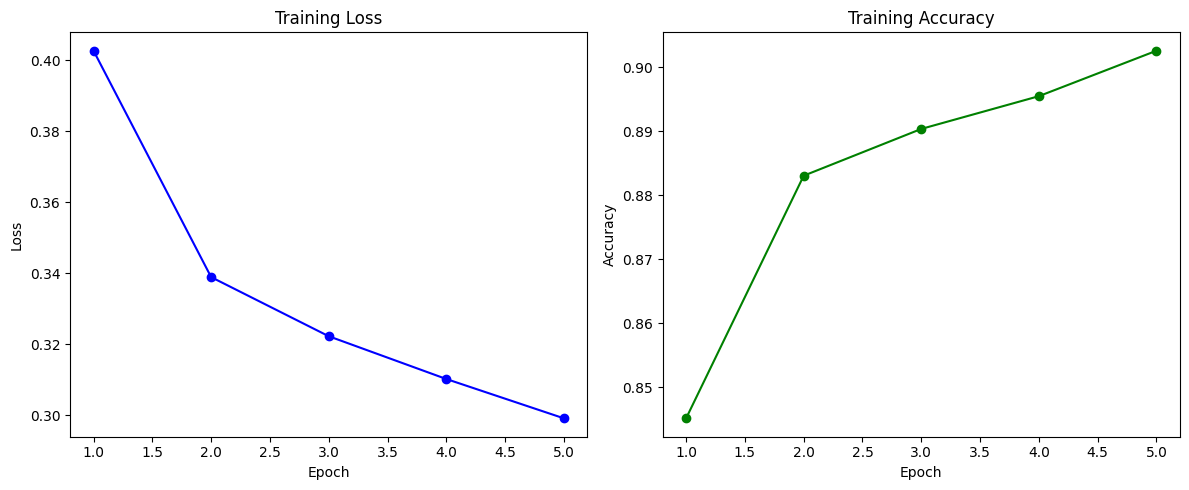

Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]


Classification Report:
               precision    recall  f1-score   support

          no       0.91      0.91      0.91      1027
         yes       0.91      0.91      0.91      1027

    accuracy                           0.91      2054
   macro avg       0.91      0.91      0.91      2054
weighted avg       0.91      0.91      0.91      2054



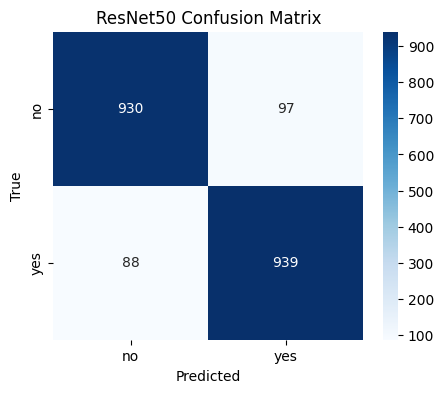

In [5]:
# ============================
# 1. Install Dependencies
# ============================

import os
import glob
import shutil
import random
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm # For notebook-friendly progress bars

# ============================
# 2. Dataset Preparation
# ============================
# Note: Adjust this path to your actual dataset location if different
base_dir = "/kaggle/input/tumor-dataset/dataset"
yes_dir = os.path.join(base_dir, "yes")
no_dir  = os.path.join(base_dir, "no")

dataset_dir = "/kaggle/working/brain_tumor_bt"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dataset_dir, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, split, "labels"), exist_ok=True)

def write_label(img_path, out_dir, label_id):
    label_txt = os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    with open(os.path.join(out_dir, label_txt), "w") as f:
        f.write(f"{label_id} 0.5 0.5 1.0 1.0\n")

def collect_images(src):
    valid_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
    imgs = []
    for ext in valid_exts:
        imgs.extend(glob.glob(f"{src}/**/{ext}", recursive=True))
    return imgs

# Collect images
imgs_yes = collect_images(yes_dir)
imgs_no  = collect_images(no_dir)

print(f"Total YES images: {len(imgs_yes)}")
print(f"Total NO images: {len(imgs_no)}")

# ============================
# 3. Stratified Split
# ============================
def stratified_split(imgs_yes, imgs_no, test_size=0.15, val_size=0.15):
    train_yes, test_yes = train_test_split(imgs_yes, test_size=test_size, random_state=42)
    train_yes, val_yes  = train_test_split(train_yes, test_size=val_size/(1-test_size), random_state=42)
    
    train_no, test_no = train_test_split(imgs_no, test_size=test_size, random_state=42)
    train_no, val_no  = train_test_split(train_no, test_size=val_size/(1-test_size), random_state=42)

    train = [(f,1) for f in train_yes] + [(f,0) for f in train_no]
    val   = [(f,1) for f in val_yes]   + [(f,0) for f in val_no]
    test  = [(f,1) for f in test_yes]  + [(f,0) for f in test_no]
    return train, val, test

train, val, test = stratified_split(imgs_yes, imgs_no)

# ============================
# 4. Move images into class subfolders
# ============================
for split in ["train", "val", "test"]:
    for cls_name in ["no", "yes"]:
        os.makedirs(os.path.join(dataset_dir, split, "images", cls_name), exist_ok=True)

def move_images(split_data, split_name):
    # Added tqdm here for file copying progress
    for f, cls in tqdm(split_data, desc=f"Copying {split_name} images"):
        cls_name = "yes" if cls==1 else "no"
        dest = os.path.join(dataset_dir, split_name, "images", cls_name, os.path.basename(f))
        shutil.copy(f, dest)
        out_lbl = os.path.join(dataset_dir, split_name, "labels")
        write_label(f, out_lbl, cls)

move_images(train, "train")
move_images(val, "val")
move_images(test, "test")

# Debug counts
for split in ["train", "val", "test"]:
    img_dir_yes = os.path.join(dataset_dir, split, "images", "yes")
    img_dir_no = os.path.join(dataset_dir, split, "images", "no")
    lbl_dir = os.path.join(dataset_dir, split, "labels")
    num_images = len(os.listdir(img_dir_yes)) + len(os.listdir(img_dir_no))
    print(f"{split.upper()} - Images: {num_images}, Labels: {len(os.listdir(lbl_dir))}")

# ============================
# 5. ResNet50 Classification
# ============================

# Data transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.ToTensor(),
])


train_dataset = datasets.ImageFolder(os.path.join(dataset_dir, "train/images"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(dataset_dir, "val/images"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(dataset_dir, "test/images"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load pre-trained ResNet50 (using updated 'weights' argument)
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),      # prevent overfitting
    nn.Linear(num_ftrs, 2)    # binary classification
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Handle multi-GPU
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs! 🚀")
    # Wrap the model with DataParallel
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

# ============================
# 6. Training loop with accuracy
# ============================
epochs = 5
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Added tqdm here for training progress per epoch
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Optional: Update progress bar with live stats
        progress_bar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

# ============================
# 7. Plot training loss and accuracy
# ============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, marker='o', color='blue')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_accuracies, marker='o', color='green')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# ============================
# 8. Evaluation
# ============================
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    # Added tqdm here for evaluation progress
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification report
class_names = ["no", "yes"]
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet50 Confusion Matrix")
plt.show()

# VGG19 5 epoch

Total YES images: 6846
Total NO images: 6846


Copying train images:   0%|          | 0/9584 [00:00<?, ?it/s]

Copying val images:   0%|          | 0/2054 [00:00<?, ?it/s]

Copying test images:   0%|          | 0/2054 [00:00<?, ?it/s]

TRAIN - Images: 9584, Labels: 6248
VAL - Images: 2054, Labels: 1891
TEST - Images: 2054, Labels: 1898


...

Epoch 3/5 - Loss: 0.3422 - Accuracy: 0.8806


Epoch 4/5:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 4/5 - Loss: 0.3381 - Accuracy: 0.8836


Epoch 5/5:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 5/5 - Loss: 0.3289 - Accuracy: 0.8904


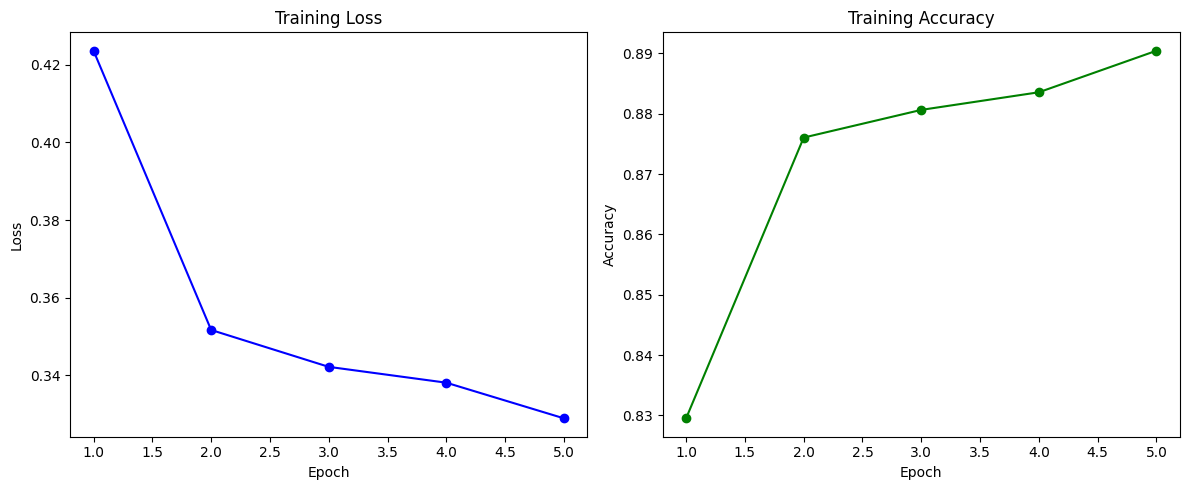

Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]


Classification Report:
               precision    recall  f1-score   support

          no       0.80      0.94      0.87      1027
         yes       0.93      0.77      0.84      1027

    accuracy                           0.86      2054
   macro avg       0.87      0.86      0.86      2054
weighted avg       0.87      0.86      0.86      2054



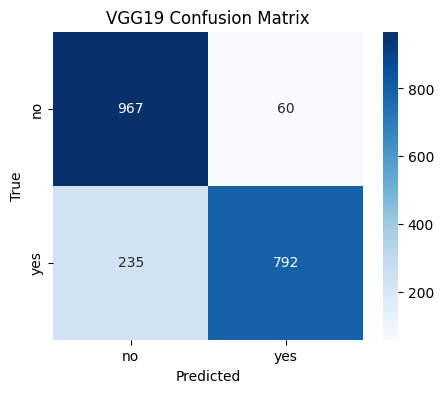

In [6]:
# ============================
# 1. Install Dependencies
# ============================

import os
import glob
import shutil
import random
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm # For notebook-friendly progress bars

# ============================
# 2. Dataset Preparation
# ============================
# Note: Adjust this path to your actual dataset location if different
base_dir = "/kaggle/input/tumor-dataset/dataset"
yes_dir = os.path.join(base_dir, "yes")
no_dir  = os.path.join(base_dir, "no")

dataset_dir = "/kaggle/working/brain_tumor_bt"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dataset_dir, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, split, "labels"), exist_ok=True)

def write_label(img_path, out_dir, label_id):
    label_txt = os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    with open(os.path.join(out_dir, label_txt), "w") as f:
        f.write(f"{label_id} 0.5 0.5 1.0 1.0\n")

def collect_images(src):
    valid_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
    imgs = []
    for ext in valid_exts:
        imgs.extend(glob.glob(f"{src}/**/{ext}", recursive=True))
    return imgs

# Collect images
imgs_yes = collect_images(yes_dir)
imgs_no  = collect_images(no_dir)

print(f"Total YES images: {len(imgs_yes)}")
print(f"Total NO images: {len(imgs_no)}")

# ============================
# 3. Stratified Split
# ============================
def stratified_split(imgs_yes, imgs_no, test_size=0.15, val_size=0.15):
    train_yes, test_yes = train_test_split(imgs_yes, test_size=test_size, random_state=42)
    train_yes, val_yes  = train_test_split(train_yes, test_size=val_size/(1-test_size), random_state=42)
    
    train_no, test_no = train_test_split(imgs_no, test_size=test_size, random_state=42)
    train_no, val_no  = train_test_split(train_no, test_size=val_size/(1-test_size), random_state=42)

    train = [(f,1) for f in train_yes] + [(f,0) for f in train_no]
    val   = [(f,1) for f in val_yes]   + [(f,0) for f in val_no]
    test  = [(f,1) for f in test_yes]  + [(f,0) for f in test_no]
    return train, val, test

train, val, test = stratified_split(imgs_yes, imgs_no)

# ============================
# 4. Move images into class subfolders
# ============================
for split in ["train", "val", "test"]:
    for cls_name in ["no", "yes"]:
        os.makedirs(os.path.join(dataset_dir, split, "images", cls_name), exist_ok=True)

def move_images(split_data, split_name):
    # Added tqdm here for file copying progress
    for f, cls in tqdm(split_data, desc=f"Copying {split_name} images"):
        cls_name = "yes" if cls==1 else "no"
        dest = os.path.join(dataset_dir, split_name, "images", cls_name, os.path.basename(f))
        shutil.copy(f, dest)
        out_lbl = os.path.join(dataset_dir, split_name, "labels")
        write_label(f, out_lbl, cls)

move_images(train, "train")
move_images(val, "val")
move_images(test, "test")

# Debug counts
for split in ["train", "val", "test"]:
    img_dir_yes = os.path.join(dataset_dir, split, "images", "yes")
    img_dir_no = os.path.join(dataset_dir, split, "images", "no")
    lbl_dir = os.path.join(dataset_dir, split, "labels")
    num_images = len(os.listdir(img_dir_yes)) + len(os.listdir(img_dir_no))
    print(f"{split.upper()} - Images: {num_images}, Labels: {len(os.listdir(lbl_dir))}")

# ============================
# 5. VGG19 Classification
# ============================

# Data transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(os.path.join(dataset_dir, "train/images"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(dataset_dir, "val/images"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(dataset_dir, "test/images"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load pre-trained VGG19 (using updated 'weights' argument)
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Sequential(
    nn.Dropout(0.5),      # prevent overfitting
    nn.Linear(num_ftrs, 2)    # binary classification
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Handle multi-GPU
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs! 🚀")
    # Wrap the model with DataParallel
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

# ============================
# 6. Training loop with accuracy
# ============================
epochs = 5
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Added tqdm here for training progress per epoch
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Optional: Update progress bar with live stats
        progress_bar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

# ============================
# 7. Plot training loss and accuracy
# ============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, marker='o', color='blue')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_accuracies, marker='o', color='green')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# ============================
# 8. Evaluation
# ============================
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    # Added tqdm here for evaluation progress
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification report
class_names = ["no", "yes"]
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("VGG19 Confusion Matrix")
plt.show()

# DENSENET 5 epoch

Total YES images: 6846
Total NO images: 6846


Copying train images:   0%|          | 0/9584 [00:00<?, ?it/s]

Copying val images:   0%|          | 0/2054 [00:00<?, ?it/s]

Copying test images:   0%|          | 0/2054 [00:00<?, ?it/s]

TRAIN - Images: 9584, Labels: 6248
VAL - Images: 2054, Labels: 1891
TEST - Images: 2054, Labels: 1898


...

Epoch 3/5 - Loss: 0.3356 - Accuracy: 0.8879


Epoch 4/5:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 4/5 - Loss: 0.3195 - Accuracy: 0.8940


Epoch 5/5:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 5/5 - Loss: 0.3157 - Accuracy: 0.8975


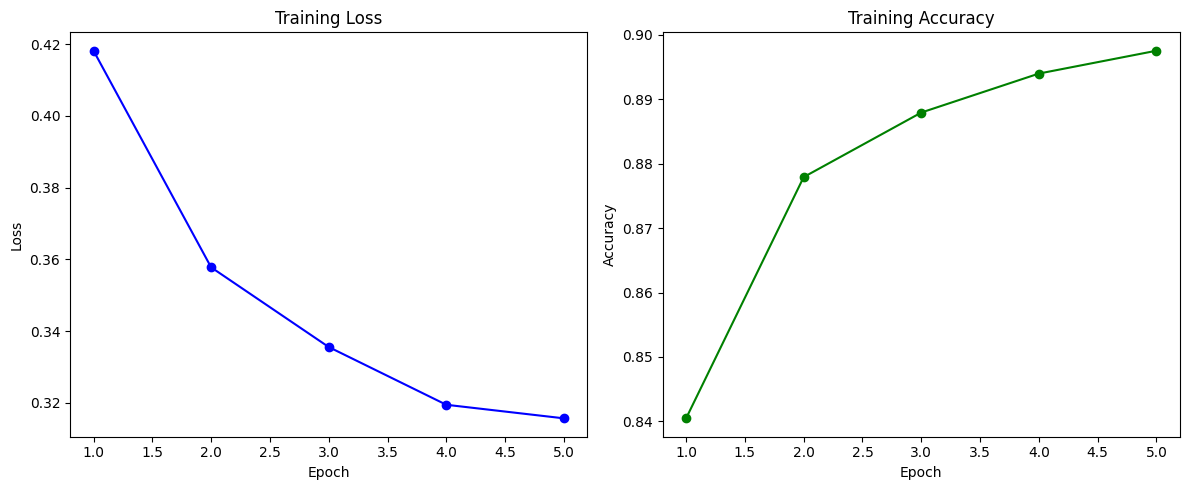

Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]


Classification Report:
               precision    recall  f1-score   support

          no       0.91      0.91      0.91      1027
         yes       0.91      0.91      0.91      1027

    accuracy                           0.91      2054
   macro avg       0.91      0.91      0.91      2054
weighted avg       0.91      0.91      0.91      2054



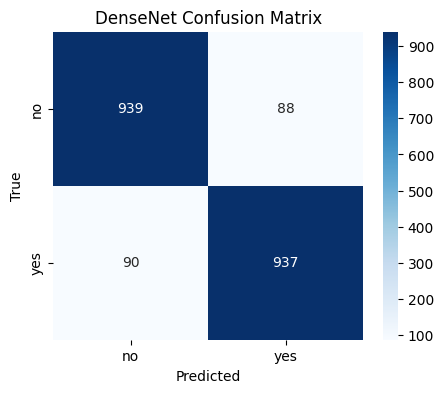

In [7]:
# ============================
# 1. Install Dependencies
# ============================

import os
import glob
import shutil
import random
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm # For notebook-friendly progress bars

# ============================
# 2. Dataset Preparation
# ============================
# Note: Adjust this path to your actual dataset location if different
base_dir = "/kaggle/input/tumor-dataset/dataset"
yes_dir = os.path.join(base_dir, "yes")
no_dir  = os.path.join(base_dir, "no")

dataset_dir = "/kaggle/working/brain_tumor_bt"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dataset_dir, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, split, "labels"), exist_ok=True)

def write_label(img_path, out_dir, label_id):
    label_txt = os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    with open(os.path.join(out_dir, label_txt), "w") as f:
        f.write(f"{label_id} 0.5 0.5 1.0 1.0\n")

def collect_images(src):
    valid_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
    imgs = []
    for ext in valid_exts:
        imgs.extend(glob.glob(f"{src}/**/{ext}", recursive=True))
    return imgs

# Collect images
imgs_yes = collect_images(yes_dir)
imgs_no  = collect_images(no_dir)

print(f"Total YES images: {len(imgs_yes)}")
print(f"Total NO images: {len(imgs_no)}")

# ============================
# 3. Stratified Split
# ============================
def stratified_split(imgs_yes, imgs_no, test_size=0.15, val_size=0.15):
    train_yes, test_yes = train_test_split(imgs_yes, test_size=test_size, random_state=42)
    train_yes, val_yes  = train_test_split(train_yes, test_size=val_size/(1-test_size), random_state=42)
    
    train_no, test_no = train_test_split(imgs_no, test_size=test_size, random_state=42)
    train_no, val_no  = train_test_split(train_no, test_size=val_size/(1-test_size), random_state=42)

    train = [(f,1) for f in train_yes] + [(f,0) for f in train_no]
    val   = [(f,1) for f in val_yes]   + [(f,0) for f in val_no]
    test  = [(f,1) for f in test_yes]  + [(f,0) for f in test_no]
    return train, val, test

train, val, test = stratified_split(imgs_yes, imgs_no)

# ============================
# 4. Move images into class subfolders
# ============================
for split in ["train", "val", "test"]:
    for cls_name in ["no", "yes"]:
        os.makedirs(os.path.join(dataset_dir, split, "images", cls_name), exist_ok=True)

def move_images(split_data, split_name):
    # Added tqdm here for file copying progress
    for f, cls in tqdm(split_data, desc=f"Copying {split_name} images"):
        cls_name = "yes" if cls==1 else "no"
        dest = os.path.join(dataset_dir, split_name, "images", cls_name, os.path.basename(f))
        shutil.copy(f, dest)
        out_lbl = os.path.join(dataset_dir, split_name, "labels")
        write_label(f, out_lbl, cls)

move_images(train, "train")
move_images(val, "val")
move_images(test, "test")

# Debug counts
for split in ["train", "val", "test"]:
    img_dir_yes = os.path.join(dataset_dir, split, "images", "yes")
    img_dir_no = os.path.join(dataset_dir, split, "images", "no")
    lbl_dir = os.path.join(dataset_dir, split, "labels")
    num_images = len(os.listdir(img_dir_yes)) + len(os.listdir(img_dir_no))
    print(f"{split.upper()} - Images: {num_images}, Labels: {len(os.listdir(lbl_dir))}")

# ============================
# 5. DenseNet Classification
# ============================

# Data transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(os.path.join(dataset_dir, "train/images"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(dataset_dir, "val/images"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(dataset_dir, "test/images"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load pre-trained DenseNet (using updated 'weights' argument)
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
num_ftrs = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.5),      # prevent overfitting
    nn.Linear(num_ftrs, 2)    # binary classification
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Handle multi-GPU
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs! 🚀")
    # Wrap the model with DataParallel
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

# ============================
# 6. Training loop with accuracy
# ============================
epochs = 5
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Added tqdm here for training progress per epoch
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Optional: Update progress bar with live stats
        progress_bar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

# ============================
# 7. Plot training loss and accuracy
# ============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, marker='o', color='blue')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_accuracies, marker='o', color='green')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# ============================
# 8. Evaluation
# ============================
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    # Added tqdm here for evaluation progress
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification report
class_names = ["no", "yes"]
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DenseNet Confusion Matrix")
plt.show()

# EfficientNet 5 epochs

Total YES images: 6846
Total NO images: 6846


Copying train images:   0%|          | 0/9584 [00:00<?, ?it/s]

Copying val images:   0%|          | 0/2054 [00:00<?, ?it/s]

Copying test images:   0%|          | 0/2054 [00:00<?, ?it/s]

TRAIN - Images: 9584, Labels: 6248
VAL - Images: 2054, Labels: 1891
TEST - Images: 2054, Labels: 1898


...

Epoch 3/5 - Loss: 0.3358 - Accuracy: 0.8842


Epoch 4/5:   0%|          | 0/299 [00:00<?, ?it/s]

Epoch 4/5 - Loss: 0.3246 - Accuracy: 0.8902


Epoch 5/5:   0%|          | 0/299 [00:00<?, ?it/s]

Epoch 5/5 - Loss: 0.3056 - Accuracy: 0.8995


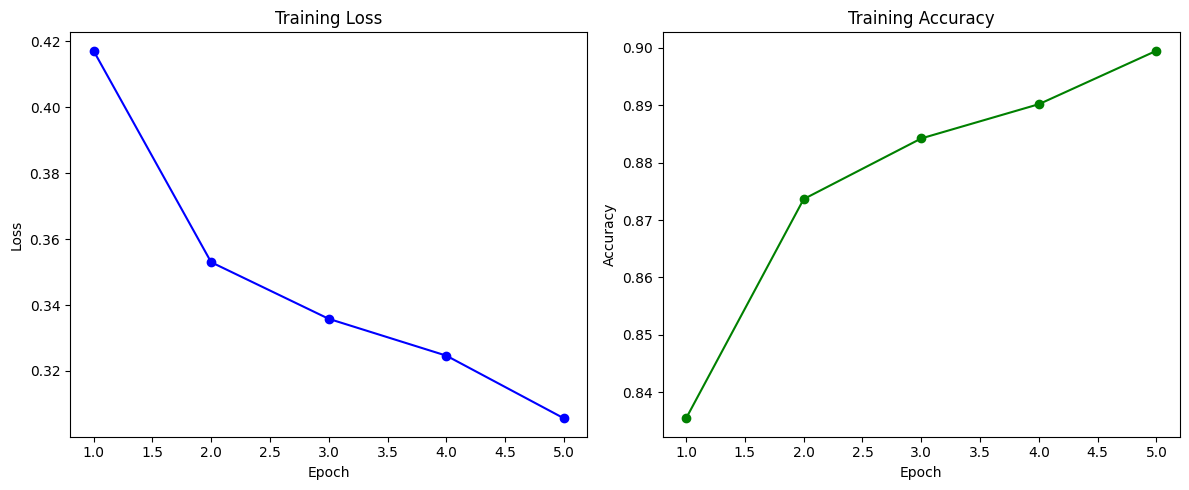

Evaluating:   0%|          | 0/64 [00:00<?, ?it/s]


Classification Report:
               precision    recall  f1-score   support

          no       0.90      0.92      0.91      1027
         yes       0.92      0.90      0.91      1021

    accuracy                           0.91      2048
   macro avg       0.91      0.91      0.91      2048
weighted avg       0.91      0.91      0.91      2048



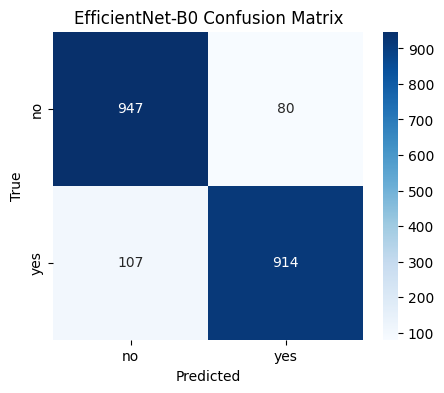

In [1]:
# ============================
# 1. Install Dependencies
# ============================

import os
import glob
import shutil
import random
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm # For notebook-friendly progress bars

# ============================
# 2. Dataset Preparation
# ============================
# Note: Adjust this path to your actual dataset location if different
base_dir = "/kaggle/input/tumor-dataset/dataset"
yes_dir = os.path.join(base_dir, "yes")
no_dir  = os.path.join(base_dir, "no")

dataset_dir = "/kaggle/working/brain_tumor_bt"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dataset_dir, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, split, "labels"), exist_ok=True)

def write_label(img_path, out_dir, label_id):
    label_txt = os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    with open(os.path.join(out_dir, label_txt), "w") as f:
        f.write(f"{label_id} 0.5 0.5 1.0 1.0\n")

def collect_images(src):
    valid_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
    imgs = []
    for ext in valid_exts:
        imgs.extend(glob.glob(f"{src}/**/{ext}", recursive=True))
    return imgs

# Collect images
imgs_yes = collect_images(yes_dir)
imgs_no  = collect_images(no_dir)

print(f"Total YES images: {len(imgs_yes)}")
print(f"Total NO images: {len(imgs_no)}")

# ============================
# 3. Stratified Split
# ============================
def stratified_split(imgs_yes, imgs_no, test_size=0.15, val_size=0.15):
    train_yes, test_yes = train_test_split(imgs_yes, test_size=test_size, random_state=42)
    train_yes, val_yes  = train_test_split(train_yes, test_size=val_size/(1-test_size), random_state=42)
    
    train_no, test_no = train_test_split(imgs_no, test_size=test_size, random_state=42)
    train_no, val_no  = train_test_split(train_no, test_size=val_size/(1-test_size), random_state=42)

    train = [(f,1) for f in train_yes] + [(f,0) for f in train_no]
    val   = [(f,1) for f in val_yes]   + [(f,0) for f in val_no]
    test  = [(f,1) for f in test_yes]  + [(f,0) for f in test_no]
    return train, val, test

train, val, test = stratified_split(imgs_yes, imgs_no)

# ============================
# 4. Move images into class subfolders
# ============================
for split in ["train", "val", "test"]:
    for cls_name in ["no", "yes"]:
        os.makedirs(os.path.join(dataset_dir, split, "images", cls_name), exist_ok=True)

def move_images(split_data, split_name):
    # Added tqdm here for file copying progress
    for f, cls in tqdm(split_data, desc=f"Copying {split_name} images"):
        cls_name = "yes" if cls == 1 else "no"
        dest = os.path.join(dataset_dir, split_name, "images", cls_name, os.path.basename(f))
        shutil.copy(f, dest)
        out_lbl = os.path.join(dataset_dir, split_name, "labels")
        write_label(f, out_lbl, cls)

move_images(train, "train")
move_images(val, "val")
move_images(test, "test")

# Debug counts
for split in ["train", "val", "test"]:
    img_dir_yes = os.path.join(dataset_dir, split, "images", "yes")
    img_dir_no = os.path.join(dataset_dir, split, "images", "no")
    lbl_dir = os.path.join(dataset_dir, split, "labels")
    num_images = len(os.listdir(img_dir_yes)) + len(os.listdir(img_dir_no))
    print(f"{split.upper()} - Images: {num_images}, Labels: {len(os.listdir(lbl_dir))}")

# ============================
# 5. EfficientNet Classification
# ============================

# Data transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(os.path.join(dataset_dir, "train/images"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(dataset_dir, "val/images"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(dataset_dir, "test/images"), transform=transform)

# DataLoader with drop_last=True to prevent CUDA error with DataParallel
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, drop_last=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=True)

# Load pre-trained EfficientNet (using updated 'weights' argument)
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Dropout(0.5),      # prevent overfitting
    nn.Linear(num_ftrs, 2)    # binary classification
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Handle multi-GPU
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs! 🚀")
    # Wrap the model with DataParallel
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

# ============================
# 6. Training loop with accuracy
# ============================
epochs = 5
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Added tqdm here for training progress per epoch
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Optional: Update progress bar with live stats
        progress_bar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

# ============================
# 7. Plot training loss and accuracy
# ============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, marker='o', color='blue')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_accuracies, marker='o', color='green')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# ============================
# 8. Evaluation
# ============================
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    # Added tqdm here for evaluation progress
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification report
class_names = ["no", "yes"]
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EfficientNet-B0 Confusion Matrix")
plt.show()

# CONVNEXT 10 epochs

Total YES images: 6846
Total NO images: 6846


Copying train images:   0%|          | 0/9584 [00:00<?, ?it/s]

Copying val images:   0%|          | 0/2054 [00:00<?, ?it/s]

Copying test images:   0%|          | 0/2054 [00:00<?, ?it/s]

TRAIN - Images: 9584, Labels: 6248
VAL - Images: 2054, Labels: 1891
TEST - Images: 2054, Labels: 1898


...

Epoch 8/10 - Loss: 0.3060 - Accuracy: 0.8988


Epoch 9/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.3055 - Accuracy: 0.8986


Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.3093 - Accuracy: 0.8957


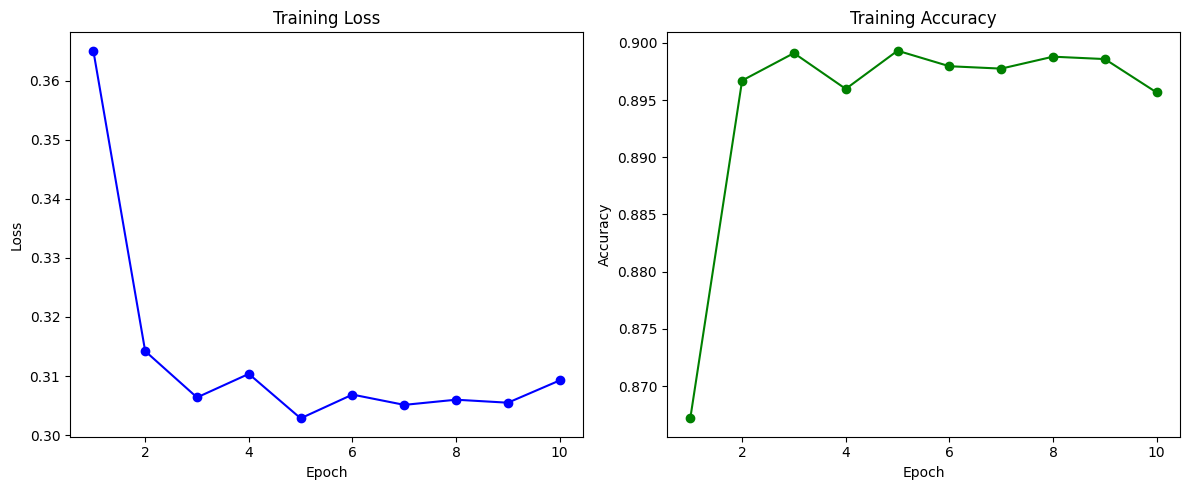

Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]


Classification Report:
               precision    recall  f1-score   support

          no       0.90      0.92      0.91      1027
         yes       0.92      0.90      0.91      1027

    accuracy                           0.91      2054
   macro avg       0.91      0.91      0.91      2054
weighted avg       0.91      0.91      0.91      2054



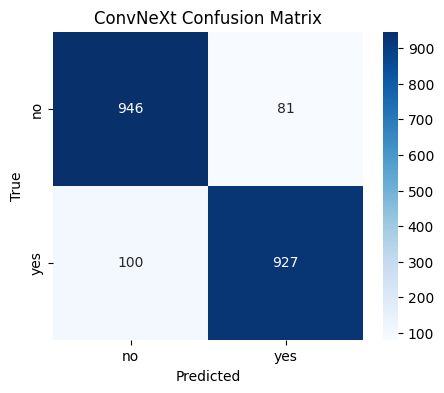

In [4]:
# ============================
# 1. Install Dependencies
# ============================

import os
import glob
import shutil
import random
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm # For notebook-friendly progress bars

# ============================
# 2. Dataset Preparation
# ============================
# Note: Adjust this path to your actual dataset location if different
base_dir = "/kaggle/input/tumor-dataset/dataset" 
yes_dir = os.path.join(base_dir, "yes")
no_dir  = os.path.join(base_dir, "no")

dataset_dir = "/kaggle/working/brain_tumor_bt"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dataset_dir, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, split, "labels"), exist_ok=True)

def write_label(img_path, out_dir, label_id):
    label_txt = os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    with open(os.path.join(out_dir, label_txt), "w") as f:
        f.write(f"{label_id} 0.5 0.5 1.0 1.0\n")

def collect_images(src):
    valid_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
    imgs = []
    for ext in valid_exts:
        imgs.extend(glob.glob(f"{src}/**/{ext}", recursive=True))
    return imgs

# Collect images
imgs_yes = collect_images(yes_dir)
imgs_no  = collect_images(no_dir)

print(f"Total YES images: {len(imgs_yes)}")
print(f"Total NO images: {len(imgs_no)}")

# ============================
# 3. Stratified Split
# ============================
def stratified_split(imgs_yes, imgs_no, test_size=0.15, val_size=0.15):
    train_yes, test_yes = train_test_split(imgs_yes, test_size=test_size, random_state=42)
    train_yes, val_yes  = train_test_split(train_yes, test_size=val_size/(1-test_size), random_state=42)
    
    train_no, test_no = train_test_split(imgs_no, test_size=test_size, random_state=42)
    train_no, val_no  = train_test_split(train_no, test_size=val_size/(1-test_size), random_state=42)

    train = [(f,1) for f in train_yes] + [(f,0) for f in train_no]
    val   = [(f,1) for f in val_yes]   + [(f,0) for f in val_no]
    test  = [(f,1) for f in test_yes]  + [(f,0) for f in test_no]
    return train, val, test

train, val, test = stratified_split(imgs_yes, imgs_no)

# ============================
# 4. Move images into class subfolders
# ============================
for split in ["train", "val", "test"]:
    for cls_name in ["no", "yes"]:
        os.makedirs(os.path.join(dataset_dir, split, "images", cls_name), exist_ok=True)

def move_images(split_data, split_name):
    # Added tqdm here for file copying progress
    for f, cls in tqdm(split_data, desc=f"Copying {split_name} images"):
        cls_name = "yes" if cls==1 else "no"
        dest = os.path.join(dataset_dir, split_name, "images", cls_name, os.path.basename(f))
        shutil.copy(f, dest)
        out_lbl = os.path.join(dataset_dir, split_name, "labels")
        write_label(f, out_lbl, cls)

move_images(train, "train")
move_images(val, "val")
move_images(test, "test")

# Debug counts
for split in ["train", "val", "test"]:
    img_dir_yes = os.path.join(dataset_dir, split, "images", "yes")
    img_dir_no = os.path.join(dataset_dir, split, "images", "no")
    lbl_dir = os.path.join(dataset_dir, split, "labels")
    num_images = len(os.listdir(img_dir_yes)) + len(os.listdir(img_dir_no))
    print(f"{split.upper()} - Images: {num_images}, Labels: {len(os.listdir(lbl_dir))}")

# ============================
# 5. ConvNeXt Classification
# ============================

# Data transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.ToTensor(),
])


train_dataset = datasets.ImageFolder(os.path.join(dataset_dir, "train/images"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(dataset_dir, "val/images"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(dataset_dir, "test/images"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load pre-trained ConvNeXt
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
num_ftrs = model.classifier[2].in_features
model.classifier[2] = nn.Sequential(
    nn.Dropout(0.5),      # prevent overfitting
    nn.Linear(num_ftrs, 2)    # binary classification
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Handle multi-GPU
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs! 🚀")
    # Wrap the model with DataParallel
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

# ============================
# 6. Training loop with accuracy
# ============================
epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Added tqdm here for training progress per epoch
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Optional: Update progress bar with live stats
        progress_bar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

# ============================
# 7. Plot training loss and accuracy
# ============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, marker='o', color='blue')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_accuracies, marker='o', color='green')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# ============================
# 8. Evaluation
# ============================
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    # Added tqdm here for evaluation progress
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification report
class_names = ["no", "yes"]
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ConvNeXt Confusion Matrix")
plt.show()

# RESNET50 10 epochs

Total YES images: 6846
Total NO images: 6846


Copying train images:   0%|          | 0/9584 [00:00<?, ?it/s]

Copying val images:   0%|          | 0/2054 [00:00<?, ?it/s]

Copying test images:   0%|          | 0/2054 [00:00<?, ?it/s]

TRAIN - Images: 9584, Labels: 6248
VAL - Images: 2054, Labels: 1891
TEST - Images: 2054, Labels: 1898


...

Epoch 8/10 - Loss: 0.2982 - Accuracy: 0.9034


Epoch 9/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.2956 - Accuracy: 0.9047


Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.2931 - Accuracy: 0.9036


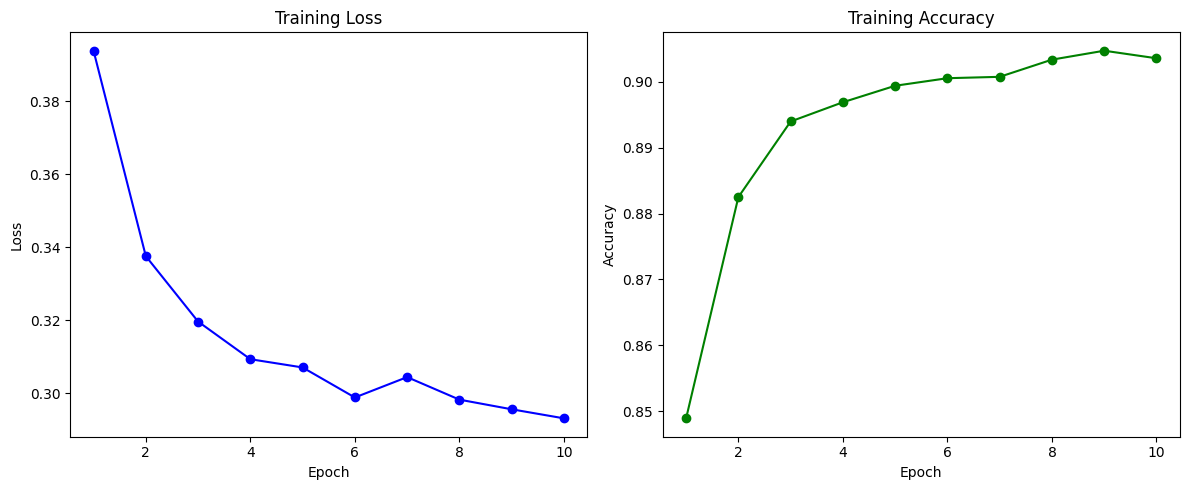

Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]


Classification Report:
               precision    recall  f1-score   support

          no       0.90      0.92      0.91      1027
         yes       0.92      0.90      0.91      1027

    accuracy                           0.91      2054
   macro avg       0.91      0.91      0.91      2054
weighted avg       0.91      0.91      0.91      2054



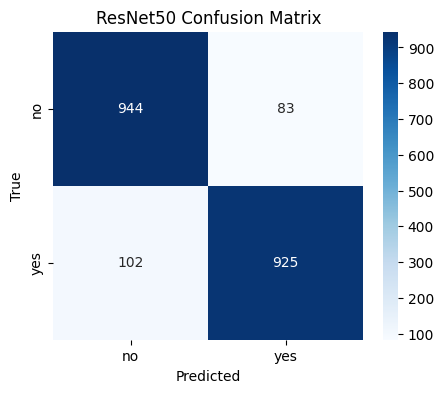

In [1]:
# ============================
# 1. Install Dependencies
# ============================

import os
import glob
import shutil
import random
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm # For notebook-friendly progress bars

# ============================
# 2. Dataset Preparation
# ============================
# Note: Adjust this path to your actual dataset location if different
base_dir = "/kaggle/input/tumor-dataset/dataset"
yes_dir = os.path.join(base_dir, "yes")
no_dir  = os.path.join(base_dir, "no")

dataset_dir = "/kaggle/working/brain_tumor_bt"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dataset_dir, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, split, "labels"), exist_ok=True)

def write_label(img_path, out_dir, label_id):
    label_txt = os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    with open(os.path.join(out_dir, label_txt), "w") as f:
        f.write(f"{label_id} 0.5 0.5 1.0 1.0\n")

def collect_images(src):
    valid_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
    imgs = []
    for ext in valid_exts:
        imgs.extend(glob.glob(f"{src}/**/{ext}", recursive=True))
    return imgs

# Collect images
imgs_yes = collect_images(yes_dir)
imgs_no  = collect_images(no_dir)

print(f"Total YES images: {len(imgs_yes)}")
print(f"Total NO images: {len(imgs_no)}")

# ============================
# 3. Stratified Split
# ============================
def stratified_split(imgs_yes, imgs_no, test_size=0.15, val_size=0.15):
    train_yes, test_yes = train_test_split(imgs_yes, test_size=test_size, random_state=42)
    train_yes, val_yes  = train_test_split(train_yes, test_size=val_size/(1-test_size), random_state=42)
    
    train_no, test_no = train_test_split(imgs_no, test_size=test_size, random_state=42)
    train_no, val_no  = train_test_split(train_no, test_size=val_size/(1-test_size), random_state=42)

    train = [(f,1) for f in train_yes] + [(f,0) for f in train_no]
    val   = [(f,1) for f in val_yes]   + [(f,0) for f in val_no]
    test  = [(f,1) for f in test_yes]  + [(f,0) for f in test_no]
    return train, val, test

train, val, test = stratified_split(imgs_yes, imgs_no)

# ============================
# 4. Move images into class subfolders
# ============================
for split in ["train", "val", "test"]:
    for cls_name in ["no", "yes"]:
        os.makedirs(os.path.join(dataset_dir, split, "images", cls_name), exist_ok=True)

def move_images(split_data, split_name):
    # Added tqdm here for file copying progress
    for f, cls in tqdm(split_data, desc=f"Copying {split_name} images"):
        cls_name = "yes" if cls==1 else "no"
        dest = os.path.join(dataset_dir, split_name, "images", cls_name, os.path.basename(f))
        shutil.copy(f, dest)
        out_lbl = os.path.join(dataset_dir, split_name, "labels")
        write_label(f, out_lbl, cls)

move_images(train, "train")
move_images(val, "val")
move_images(test, "test")

# Debug counts
for split in ["train", "val", "test"]:
    img_dir_yes = os.path.join(dataset_dir, split, "images", "yes")
    img_dir_no = os.path.join(dataset_dir, split, "images", "no")
    lbl_dir = os.path.join(dataset_dir, split, "labels")
    num_images = len(os.listdir(img_dir_yes)) + len(os.listdir(img_dir_no))
    print(f"{split.upper()} - Images: {num_images}, Labels: {len(os.listdir(lbl_dir))}")

# ============================
# 5. ResNet50 Classification
# ============================

# Data transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.ToTensor(),
])


train_dataset = datasets.ImageFolder(os.path.join(dataset_dir, "train/images"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(dataset_dir, "val/images"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(dataset_dir, "test/images"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load pre-trained ResNet50 (using updated 'weights' argument)
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),      # prevent overfitting
    nn.Linear(num_ftrs, 2)    # binary classification
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Handle multi-GPU
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs! 🚀")
    # Wrap the model with DataParallel
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

# ============================
# 6. Training loop with accuracy
# ============================
epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Added tqdm here for training progress per epoch
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Optional: Update progress bar with live stats
        progress_bar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

# ============================
# 7. Plot training loss and accuracy
# ============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, marker='o', color='blue')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_accuracies, marker='o', color='green')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# ============================
# 8. Evaluation
# ============================
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    # Added tqdm here for evaluation progress
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification report
class_names = ["no", "yes"]
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet50 Confusion Matrix")
plt.show()

# VGG19 10 epochs

Total YES images: 6846
Total NO images: 6846


Copying train images:   0%|          | 0/9584 [00:00<?, ?it/s]

Copying val images:   0%|          | 0/2054 [00:00<?, ?it/s]

Copying test images:   0%|          | 0/2054 [00:00<?, ?it/s]

TRAIN - Images: 9584, Labels: 6248
VAL - Images: 2054, Labels: 1891
TEST - Images: 2054, Labels: 1898


...

Epoch 8/10 - Loss: 0.3241 - Accuracy: 0.8915


Epoch 9/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.3194 - Accuracy: 0.8928


Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.3279 - Accuracy: 0.8891


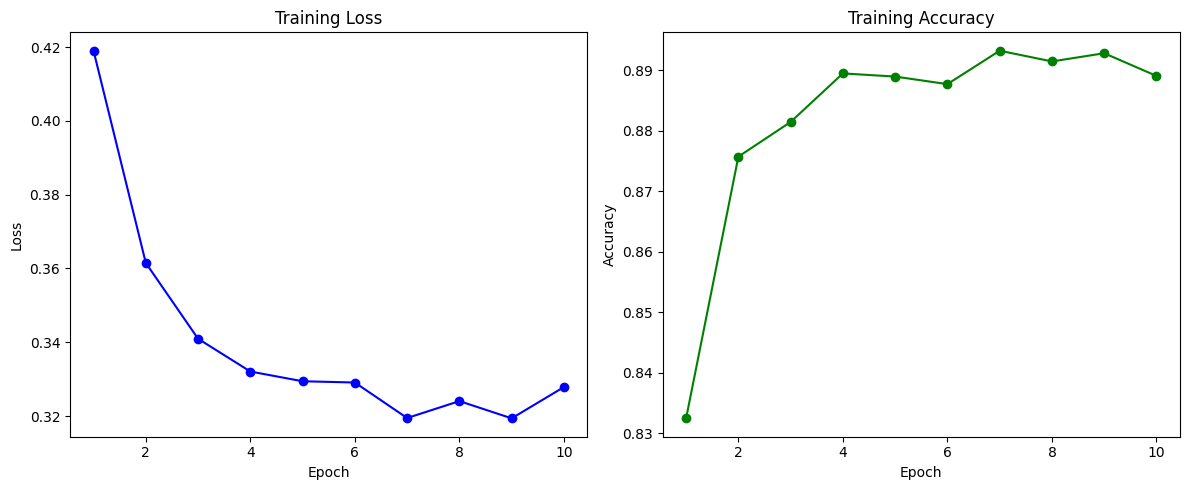

Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]


Classification Report:
               precision    recall  f1-score   support

          no       0.87      0.92      0.89      1027
         yes       0.91      0.87      0.89      1027

    accuracy                           0.89      2054
   macro avg       0.89      0.89      0.89      2054
weighted avg       0.89      0.89      0.89      2054



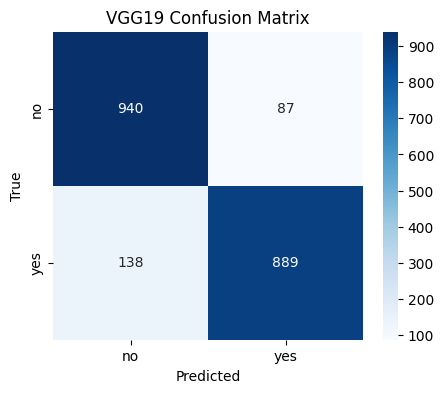

In [3]:
# ============================
# 1. Install Dependencies
# ============================

import os
import glob
import shutil
import random
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm # For notebook-friendly progress bars

# ============================
# 2. Dataset Preparation
# ============================
# Note: Adjust this path to your actual dataset location if different
base_dir = "/kaggle/input/tumor-dataset/dataset"
yes_dir = os.path.join(base_dir, "yes")
no_dir  = os.path.join(base_dir, "no")

dataset_dir = "/kaggle/working/brain_tumor_bt"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dataset_dir, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, split, "labels"), exist_ok=True)

def write_label(img_path, out_dir, label_id):
    label_txt = os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    with open(os.path.join(out_dir, label_txt), "w") as f:
        f.write(f"{label_id} 0.5 0.5 1.0 1.0\n")

def collect_images(src):
    valid_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
    imgs = []
    for ext in valid_exts:
        imgs.extend(glob.glob(f"{src}/**/{ext}", recursive=True))
    return imgs

# Collect images
imgs_yes = collect_images(yes_dir)
imgs_no  = collect_images(no_dir)

print(f"Total YES images: {len(imgs_yes)}")
print(f"Total NO images: {len(imgs_no)}")

# ============================
# 3. Stratified Split
# ============================
def stratified_split(imgs_yes, imgs_no, test_size=0.15, val_size=0.15):
    train_yes, test_yes = train_test_split(imgs_yes, test_size=test_size, random_state=42)
    train_yes, val_yes  = train_test_split(train_yes, test_size=val_size/(1-test_size), random_state=42)
    
    train_no, test_no = train_test_split(imgs_no, test_size=test_size, random_state=42)
    train_no, val_no  = train_test_split(train_no, test_size=val_size/(1-test_size), random_state=42)

    train = [(f,1) for f in train_yes] + [(f,0) for f in train_no]
    val   = [(f,1) for f in val_yes]   + [(f,0) for f in val_no]
    test  = [(f,1) for f in test_yes]  + [(f,0) for f in test_no]
    return train, val, test

train, val, test = stratified_split(imgs_yes, imgs_no)

# ============================
# 4. Move images into class subfolders
# ============================
for split in ["train", "val", "test"]:
    for cls_name in ["no", "yes"]:
        os.makedirs(os.path.join(dataset_dir, split, "images", cls_name), exist_ok=True)

def move_images(split_data, split_name):
    # Added tqdm here for file copying progress
    for f, cls in tqdm(split_data, desc=f"Copying {split_name} images"):
        cls_name = "yes" if cls==1 else "no"
        dest = os.path.join(dataset_dir, split_name, "images", cls_name, os.path.basename(f))
        shutil.copy(f, dest)
        out_lbl = os.path.join(dataset_dir, split_name, "labels")
        write_label(f, out_lbl, cls)

move_images(train, "train")
move_images(val, "val")
move_images(test, "test")

# Debug counts
for split in ["train", "val", "test"]:
    img_dir_yes = os.path.join(dataset_dir, split, "images", "yes")
    img_dir_no = os.path.join(dataset_dir, split, "images", "no")
    lbl_dir = os.path.join(dataset_dir, split, "labels")
    num_images = len(os.listdir(img_dir_yes)) + len(os.listdir(img_dir_no))
    print(f"{split.upper()} - Images: {num_images}, Labels: {len(os.listdir(lbl_dir))}")

# ============================
# 5. VGG19 Classification
# ============================

# Data transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(os.path.join(dataset_dir, "train/images"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(dataset_dir, "val/images"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(dataset_dir, "test/images"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load pre-trained VGG19 (using updated 'weights' argument)
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Sequential(
    nn.Dropout(0.5),      # prevent overfitting
    nn.Linear(num_ftrs, 2)    # binary classification
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Handle multi-GPU
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs! 🚀")
    # Wrap the model with DataParallel
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

# ============================
# 6. Training loop with accuracy
# ============================
epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Added tqdm here for training progress per epoch
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Optional: Update progress bar with live stats
        progress_bar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

# ============================
# 7. Plot training loss and accuracy
# ============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, marker='o', color='blue')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_accuracies, marker='o', color='green')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# ============================
# 8. Evaluation
# ============================
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    # Added tqdm here for evaluation progress
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification report
class_names = ["no", "yes"]
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("VGG19 Confusion Matrix")
plt.show()

# DENSENET 10 epoch

Total YES images: 6846
Total NO images: 6846


Copying train images:   0%|          | 0/9584 [00:00<?, ?it/s]

Copying val images:   0%|          | 0/2054 [00:00<?, ?it/s]

Copying test images:   0%|          | 0/2054 [00:00<?, ?it/s]

TRAIN - Images: 9584, Labels: 6248
VAL - Images: 2054, Labels: 1891
TEST - Images: 2054, Labels: 1898


...

Epoch 8/10 - Loss: 0.3046 - Accuracy: 0.8994


Epoch 9/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.2972 - Accuracy: 0.9027


Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.2996 - Accuracy: 0.9037


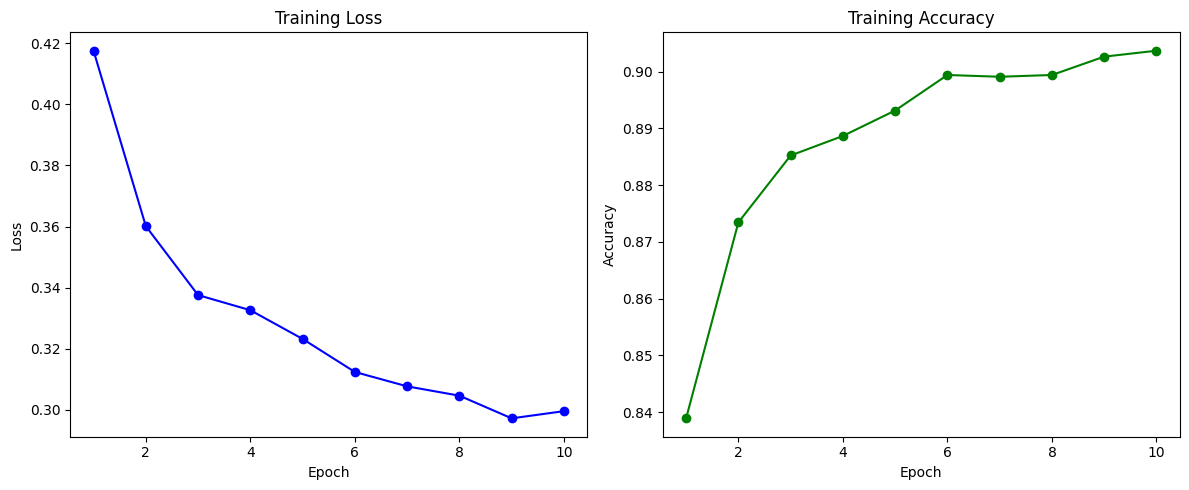

Evaluating:   0%|          | 0/65 [00:00<?, ?it/s]


Classification Report:
               precision    recall  f1-score   support

          no       0.91      0.92      0.91      1027
         yes       0.92      0.91      0.91      1027

    accuracy                           0.91      2054
   macro avg       0.91      0.91      0.91      2054
weighted avg       0.91      0.91      0.91      2054



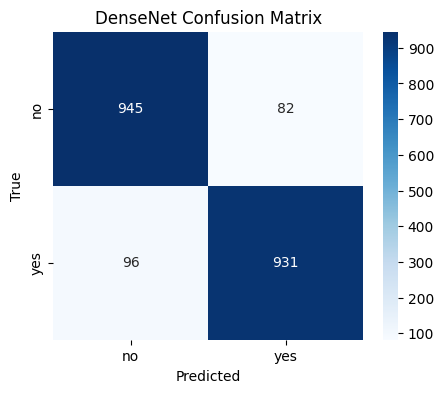

In [2]:
# ============================
# 1. Install Dependencies
# ============================

import os
import glob
import shutil
import random
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm # For notebook-friendly progress bars

# ============================
# 2. Dataset Preparation
# ============================
# Note: Adjust this path to your actual dataset location if different
base_dir = "/kaggle/input/tumor-dataset/dataset"
yes_dir = os.path.join(base_dir, "yes")
no_dir  = os.path.join(base_dir, "no")

dataset_dir = "/kaggle/working/brain_tumor_bt"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dataset_dir, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, split, "labels"), exist_ok=True)

def write_label(img_path, out_dir, label_id):
    label_txt = os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    with open(os.path.join(out_dir, label_txt), "w") as f:
        f.write(f"{label_id} 0.5 0.5 1.0 1.0\n")

def collect_images(src):
    valid_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
    imgs = []
    for ext in valid_exts:
        imgs.extend(glob.glob(f"{src}/**/{ext}", recursive=True))
    return imgs

# Collect images
imgs_yes = collect_images(yes_dir)
imgs_no  = collect_images(no_dir)

print(f"Total YES images: {len(imgs_yes)}")
print(f"Total NO images: {len(imgs_no)}")

# ============================
# 3. Stratified Split
# ============================
def stratified_split(imgs_yes, imgs_no, test_size=0.15, val_size=0.15):
    train_yes, test_yes = train_test_split(imgs_yes, test_size=test_size, random_state=42)
    train_yes, val_yes  = train_test_split(train_yes, test_size=val_size/(1-test_size), random_state=42)
    
    train_no, test_no = train_test_split(imgs_no, test_size=test_size, random_state=42)
    train_no, val_no  = train_test_split(train_no, test_size=val_size/(1-test_size), random_state=42)

    train = [(f,1) for f in train_yes] + [(f,0) for f in train_no]
    val   = [(f,1) for f in val_yes]   + [(f,0) for f in val_no]
    test  = [(f,1) for f in test_yes]  + [(f,0) for f in test_no]
    return train, val, test

train, val, test = stratified_split(imgs_yes, imgs_no)

# ============================
# 4. Move images into class subfolders
# ============================
for split in ["train", "val", "test"]:
    for cls_name in ["no", "yes"]:
        os.makedirs(os.path.join(dataset_dir, split, "images", cls_name), exist_ok=True)

def move_images(split_data, split_name):
    # Added tqdm here for file copying progress
    for f, cls in tqdm(split_data, desc=f"Copying {split_name} images"):
        cls_name = "yes" if cls==1 else "no"
        dest = os.path.join(dataset_dir, split_name, "images", cls_name, os.path.basename(f))
        shutil.copy(f, dest)
        out_lbl = os.path.join(dataset_dir, split_name, "labels")
        write_label(f, out_lbl, cls)

move_images(train, "train")
move_images(val, "val")
move_images(test, "test")

# Debug counts
for split in ["train", "val", "test"]:
    img_dir_yes = os.path.join(dataset_dir, split, "images", "yes")
    img_dir_no = os.path.join(dataset_dir, split, "images", "no")
    lbl_dir = os.path.join(dataset_dir, split, "labels")
    num_images = len(os.listdir(img_dir_yes)) + len(os.listdir(img_dir_no))
    print(f"{split.upper()} - Images: {num_images}, Labels: {len(os.listdir(lbl_dir))}")

# ============================
# 5. DenseNet Classification
# ============================

# Data transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(os.path.join(dataset_dir, "train/images"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(dataset_dir, "val/images"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(dataset_dir, "test/images"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load pre-trained DenseNet (using updated 'weights' argument)
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
num_ftrs = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.5),      # prevent overfitting
    nn.Linear(num_ftrs, 2)    # binary classification
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Handle multi-GPU
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs! 🚀")
    # Wrap the model with DataParallel
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

# ============================
# 6. Training loop with accuracy
# ============================
epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Added tqdm here for training progress per epoch
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Optional: Update progress bar with live stats
        progress_bar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

# ============================
# 7. Plot training loss and accuracy
# ============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, marker='o', color='blue')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_accuracies, marker='o', color='green')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# ============================
# 8. Evaluation
# ============================
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    # Added tqdm here for evaluation progress
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification report
class_names = ["no", "yes"]
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DenseNet Confusion Matrix")
plt.show()

# EfficientNet 10 epochs

Total YES images: 6846
Total NO images: 6846


Copying train images:   0%|          | 0/9584 [00:00<?, ?it/s]

Copying val images:   0%|          | 0/2054 [00:00<?, ?it/s]

Copying test images:   0%|          | 0/2054 [00:00<?, ?it/s]

TRAIN - Images: 9584, Labels: 6248
VAL - Images: 2054, Labels: 1891
TEST - Images: 2054, Labels: 1898
Let's use 2 GPUs! 🚀


...

Epoch 8/10 - Loss: 0.2960 - Accuracy: 0.9044


Epoch 9/10:   0%|          | 0/299 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.2905 - Accuracy: 0.9062


Epoch 10/10:   0%|          | 0/299 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.2883 - Accuracy: 0.9056


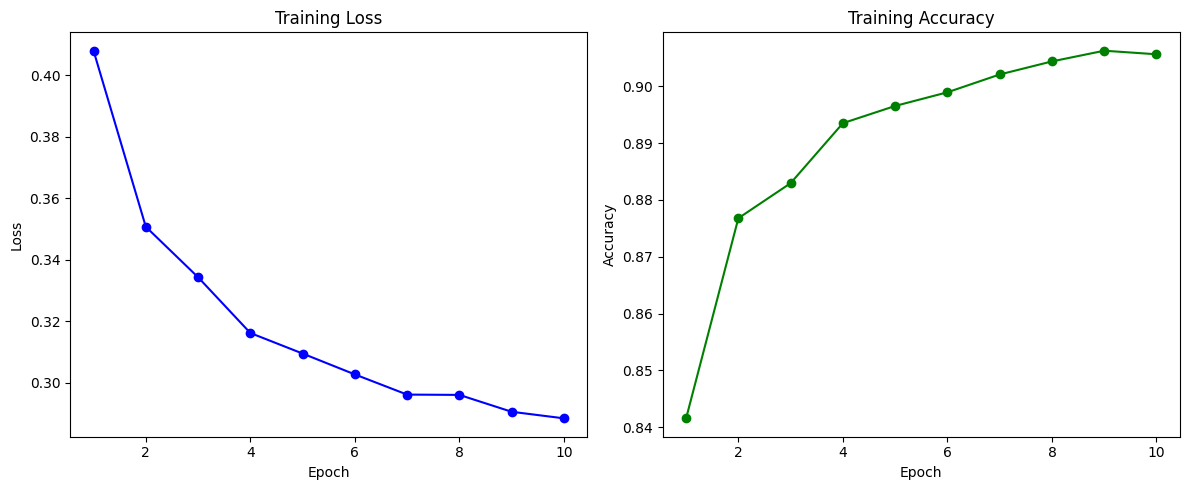

Evaluating:   0%|          | 0/64 [00:00<?, ?it/s]


Classification Report:
               precision    recall  f1-score   support

          no       0.91      0.92      0.92      1027
         yes       0.92      0.91      0.92      1021

    accuracy                           0.92      2048
   macro avg       0.92      0.92      0.92      2048
weighted avg       0.92      0.92      0.92      2048



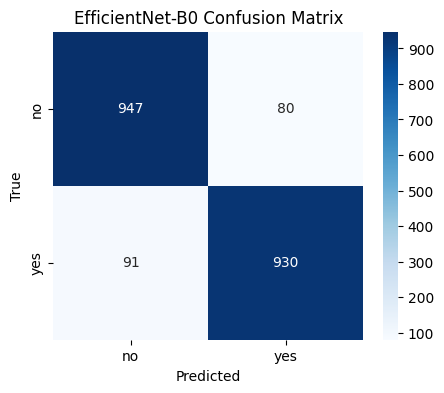

In [2]:
# ============================
# 1. Install Dependencies
# ============================

import os
import glob
import shutil
import random
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm # For notebook-friendly progress bars

# ============================
# 2. Dataset Preparation
# ============================
# Note: Adjust this path to your actual dataset location if different
base_dir = "/kaggle/input/tumor-dataset/dataset"
yes_dir = os.path.join(base_dir, "yes")
no_dir  = os.path.join(base_dir, "no")

dataset_dir = "/kaggle/working/brain_tumor_bt"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dataset_dir, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, split, "labels"), exist_ok=True)

def write_label(img_path, out_dir, label_id):
    label_txt = os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    with open(os.path.join(out_dir, label_txt), "w") as f:
        f.write(f"{label_id} 0.5 0.5 1.0 1.0\n")

def collect_images(src):
    valid_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
    imgs = []
    for ext in valid_exts:
        imgs.extend(glob.glob(f"{src}/**/{ext}", recursive=True))
    return imgs

# Collect images
imgs_yes = collect_images(yes_dir)
imgs_no  = collect_images(no_dir)

print(f"Total YES images: {len(imgs_yes)}")
print(f"Total NO images: {len(imgs_no)}")

# ============================
# 3. Stratified Split
# ============================
def stratified_split(imgs_yes, imgs_no, test_size=0.15, val_size=0.15):
    train_yes, test_yes = train_test_split(imgs_yes, test_size=test_size, random_state=42)
    train_yes, val_yes  = train_test_split(train_yes, test_size=val_size/(1-test_size), random_state=42)
    
    train_no, test_no = train_test_split(imgs_no, test_size=test_size, random_state=42)
    train_no, val_no  = train_test_split(train_no, test_size=val_size/(1-test_size), random_state=42)

    train = [(f,1) for f in train_yes] + [(f,0) for f in train_no]
    val   = [(f,1) for f in val_yes]   + [(f,0) for f in val_no]
    test  = [(f,1) for f in test_yes]  + [(f,0) for f in test_no]
    return train, val, test

train, val, test = stratified_split(imgs_yes, imgs_no)

# ============================
# 4. Move images into class subfolders
# ============================
for split in ["train", "val", "test"]:
    for cls_name in ["no", "yes"]:
        os.makedirs(os.path.join(dataset_dir, split, "images", cls_name), exist_ok=True)

def move_images(split_data, split_name):
    # Added tqdm here for file copying progress
    for f, cls in tqdm(split_data, desc=f"Copying {split_name} images"):
        cls_name = "yes" if cls == 1 else "no"
        dest = os.path.join(dataset_dir, split_name, "images", cls_name, os.path.basename(f))
        shutil.copy(f, dest)
        out_lbl = os.path.join(dataset_dir, split_name, "labels")
        write_label(f, out_lbl, cls)

move_images(train, "train")
move_images(val, "val")
move_images(test, "test")

# Debug counts
for split in ["train", "val", "test"]:
    img_dir_yes = os.path.join(dataset_dir, split, "images", "yes")
    img_dir_no = os.path.join(dataset_dir, split, "images", "no")
    lbl_dir = os.path.join(dataset_dir, split, "labels")
    num_images = len(os.listdir(img_dir_yes)) + len(os.listdir(img_dir_no))
    print(f"{split.upper()} - Images: {num_images}, Labels: {len(os.listdir(lbl_dir))}")

# ============================
# 5. EfficientNet Classification
# ============================

# Data transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(os.path.join(dataset_dir, "train/images"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(dataset_dir, "val/images"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(dataset_dir, "test/images"), transform=transform)

# DataLoader with drop_last=True to prevent CUDA error with DataParallel
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, drop_last=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=True)

# Load pre-trained EfficientNet (using updated 'weights' argument)
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Dropout(0.5),      # prevent overfitting
    nn.Linear(num_ftrs, 2)    # binary classification
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Handle multi-GPU
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs! 🚀")
    # Wrap the model with DataParallel
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

# ============================
# 6. Training loop with accuracy
# ============================
epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Added tqdm here for training progress per epoch
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Optional: Update progress bar with live stats
        progress_bar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

# ============================
# 7. Plot training loss and accuracy
# ============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, marker='o', color='blue')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_accuracies, marker='o', color='green')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# ============================
# 8. Evaluation
# ============================
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    # Added tqdm here for evaluation progress
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification report
class_names = ["no", "yes"]
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EfficientNet-B0 Confusion Matrix")
plt.show()